# The PreDoc sampling strategy on a multinomial logit, from scratch

Everything below is written out: the model and its derivatives, the subproblem
solver, the radius rule, the sample-size rule and the trust-region loop. No
optimisation package is used, and the closing cell checks that
`TrustRegionRadius` was never loaded, so "from scratch" is verified rather than
asserted.

## What is being demonstrated

A trust-region method whose sample size is chosen at each iteration from a
confidence statement about the achieved decrease, on a discrete choice model
where the **information matrix equality** holds at the solution. That equality is
what makes the outer-product Hessian legitimate, and the point of the exercise is
to watch it pay off: the BHHH matrix should be a poor approximation to the
Hessian far from $\beta^*$ and a good one near it, so a trust-region method using
it should behave like gradient descent early and like Newton late, without being
told when to switch.

## The pieces

| piece | what it is |
|:--|:--|
| model | multinomial logit, $p = 5$ parameters, $J = 5$ alternatives, synthetic data |
| subproblem | Steihaug-Toint truncated conjugate gradient |
| radius rule | R-delta: $\Delta_{k+1} = \gamma_1\Delta_k$, $\gamma_2\Delta_k$ or $\gamma_3\Delta_k$ by $\rho_k$ |
| model Hessian | the exact Hessian, or BHHH $\tilde B_k = \frac1N\sum_i \nabla F_i \nabla F_i^\top$ |
| sample size | $N^+_{k+1} = \lceil z^2\hat\sigma^2_k / \hat\delta_k^2\rceil$ on paired differences |
| smoothing | $aN_k \le N_{k+1} \le bN_k$ with a floor $N^{\min}_k = N_{\min} + kN_{incr}$ |
| sample scheme | independent, nested, or prefix |

The constants are the PreDoc's: $\eta_1 = 0.01$, $\eta_2 = 0.8$,
$\gamma = (0.5, 0.9, 1.5)$, $\lvert\mathcal{S}_0\rvert = 100$, $N_{\min} = 10$,
$N_{incr} = 10$, $z_{0.95} = 1.6449$, $x_0 = 0$, $\Delta_0 = 0.1\|\tilde g_0\|$.

In [1]:
const REPO = normpath(joinpath(@__DIR__, "..", ".."))
using Pkg; Pkg.activate(joinpath(REPO, "notebooks"))

# The whole dependency list. No optimisation package, no automatic
# differentiation: every derivative below is written out by hand and checked
# against finite differences.
using LinearAlgebra, Random, Printf, Statistics, Plots

const OUTDIR = joinpath(REPO, "notebooks", "Sampling")
mkpath(OUTDIR)
println("loaded: LinearAlgebra, Random, Printf, Statistics, Plots")

  Activating project at `c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks`


loaded: LinearAlgebra, Random, Printf, Statistics, Plots


## 1. The model

Individual $n$ faces $J$ alternatives. Alternative $j$ carries an attribute
vector $x_{nj}\in\mathbb{R}^p$, and the utility it offers is
$U_{nj} = \beta^\top x_{nj} + \varepsilon_{nj}$ with independent Gumbel errors.
The chooser takes the largest, which gives the closed form

$$P_{nj}(\beta) \;=\; \frac{e^{\beta^\top x_{nj}}}{\sum_{l=1}^{J} e^{\beta^\top x_{nl}}} .$$

Maximum likelihood over $M$ individuals minimises the average negative
log-likelihood

$$f(\beta) \;=\; -\frac1M\sum_{n=1}^{M}\ln P_{n,c_n}(\beta)
             \;=\; \frac1M\sum_{n=1}^{M} F_n(\beta),
\qquad
F_n(\beta) = \ln\!\Big(\textstyle\sum_j e^{V_{nj}}\Big) - V_{nc_n},$$

where $c_n$ is the alternative $n$ actually chose and $V_{nj} = \beta^\top x_{nj}$.

### The derivatives

Write $P_n$ for the probability vector at $\beta$ and
$\bar x_n = \sum_j P_{nj}x_{nj}$ for the probability-weighted mean attribute.
Differentiating $F_n$ once and twice,

$$\nabla F_n = \bar x_n - x_{nc_n},
\qquad
\nabla^2 F_n = \sum_j P_{nj}\,x_{nj}x_{nj}^\top - \bar x_n\bar x_n^\top .$$

The second is the covariance of the attribute vector under the choice
probabilities, so it is **positive semidefinite** and $f$ is convex. Two
consequences to keep in mind: there are no saddle points to worry about, and
BHHH, which is positive semidefinite by construction, gives up nothing by being
unable to report negative curvature.

### The data

Synthetic, generated from the model itself: $x_{nj}\sim N(0,I)$, and $c_n$ drawn
from $P_n(\beta^*)$. That is what makes the model **correctly specified**, which
is the hypothesis the information matrix equality needs.

In [2]:
"A multinomial logit problem: attributes `X` of size `M × J × p`, choices `y`."
struct MNL
    p::Int                      # parameters
    J::Int                      # alternatives
    M::Int                      # individuals
    X::Array{Float64, 3}
    y::Vector{Int}
    βstar::Vector{Float64}
end

"Softmax in place, shifted by the maximum so that `exp` never overflows."
function softmax!(v)
    m = maximum(v)
    s = 0.0
    @inbounds for j in eachindex(v)
        v[j] = exp(v[j] - m)
        s += v[j]
    end
    v ./= s
    return v
end

"Utilities `V_j = β' x_{ij}` for individual `i`, written into `V`."
@inline function utilities!(V, m::MNL, β, i::Int)
    @inbounds for j in 1:m.J
        acc = 0.0
        for k in 1:m.p
            acc += m.X[i, j, k] * β[k]
        end
        V[j] = acc
    end
    return V
end

"""
    make_mnl(; p, J, M, seed, signal) -> MNL

Synthetic data generated from the logit model itself, so the specification is
correct by construction and the information matrix equality holds at `β*`.
"""
function make_mnl(; p::Int = 5, J::Int = 5, M::Int = 100_000,
                    seed::Int = 0, signal::Real = 1.0)
    rng = MersenneTwister(seed)
    β = signal .* randn(rng, p)
    X = randn(rng, M, J, p)
    y = Vector{Int}(undef, M)
    V = Vector{Float64}(undef, J)
    mtmp = MNL(p, J, M, X, y, β)
    for i in 1:M
        utilities!(V, mtmp, β, i)
        softmax!(V)
        u = rand(rng); acc = 0.0; c = J
        @inbounds for j in 1:J
            acc += V[j]
            if u < acc
                c = j; break
            end
        end
        y[i] = c
    end
    return MNL(p, J, M, X, y, β)
end

make_mnl

In [3]:
"Per-individual losses `F_i(β)` over the batch. Needed one at a time for the
 paired differences, so this returns the vector rather than its mean."
function losses(m::MNL, β, B)
    out = Vector{Float64}(undef, length(B))
    V = Vector{Float64}(undef, m.J)
    @inbounds for (t, i) in enumerate(B)
        utilities!(V, m, β, i)
        mx = maximum(V)
        se = 0.0
        for j in 1:m.J
            se += exp(V[j] - mx)
        end
        out[t] = mx + log(se) - V[m.y[i]]         # logsumexp(V) − V[c_i]
    end
    return out
end

"The batch objective, `(1/N) Σ F_i(β)`."
fhat(m::MNL, β, B) = sum(losses(m, β, B)) / length(B)

"""
    score_matrix(m, β, B) -> p × N

Column `t` is `∇F_i(β) = x̄_i − x_{i c_i}` for `i = B[t]`. This one array is all
three of the gradient, the BHHH matrix and the outer-product variance, which is
the PreDoc's argument for BHHH: it is obtained free once the gradient is wanted.
"""
function score_matrix(m::MNL, β, B)
    S = Matrix{Float64}(undef, m.p, length(B))
    P = Vector{Float64}(undef, m.J)
    @inbounds for (t, i) in enumerate(B)
        utilities!(P, m, β, i); softmax!(P)
        c = m.y[i]
        for k in 1:m.p
            acc = 0.0
            for j in 1:m.J
                acc += P[j] * m.X[i, j, k]
            end
            S[k, t] = acc - m.X[i, c, k]
        end
    end
    return S
end

"The batch gradient: the mean of the scores."
ghat(m::MNL, β, B) = (S = score_matrix(m, β, B); vec(sum(S; dims = 2)) ./ size(S, 2))

"""
    hess(m, β, B) -> p × p

The exact batch Hessian, `(1/N) Σ_i [ Σ_j P_{ij} x_{ij}x_{ij}' − x̄_i x̄_i' ]`,
formed as a weighted Gram matrix minus a rank-one correction per individual.
Only the upper triangle is accumulated.
"""
function hess(m::MNL, β, B)
    p = m.p
    H = zeros(p, p)
    P = Vector{Float64}(undef, m.J)
    xb = Vector{Float64}(undef, p)
    @inbounds for i in B
        utilities!(P, m, β, i); softmax!(P)
        fill!(xb, 0.0)
        for j in 1:m.J, k in 1:p
            xb[k] += P[j] * m.X[i, j, k]
        end
        for j in 1:m.J
            w = P[j]
            w == 0 && continue
            for a in 1:p
                wa = w * m.X[i, j, a]
                for b in a:p
                    H[a, b] += wa * m.X[i, j, b]
                end
            end
        end
        for a in 1:p, b in a:p
            H[a, b] -= xb[a] * xb[b]
        end
    end
    @inbounds for a in 1:p, b in 1:a-1
        H[a, b] = H[b, a]
    end
    return H ./ length(B)
end

"BHHH: the outer product of the scores, `(1/N) S S'`."
bhhh(S) = (S * S') ./ size(S, 2)

"""
BHHH-2: the same with the mean removed, `(1/N) Σ (∇F_i − ḡ)(∇F_i − ḡ)'`.

It differs from `bhhh` by exactly `ḡḡ'`, which vanishes at a stationary point.
Away from one the two are different matrices and the gap is worth seeing.
"""
function bhhh2(S)
    N = size(S, 2)
    ḡ = vec(sum(S; dims = 2)) ./ N
    D = S .- ḡ
    return (D * D') ./ N
end

println("model and derivatives defined")

model and derivatives defined


## 2. Checking the derivatives

Hand-written derivatives are worth exactly as much as the check on them. There is
no automatic differentiation here and no reference implementation, so the ground
truth is central differences of the function we did write.

Three things are checked: the gradient against central differences of the
objective, the Hessian against central differences of the gradient, and the
identity that the gradient is the mean of the score columns. The last is not
redundant: it is what lets BHHH be assembled from the same array the gradient
came from.

In [4]:
const PROB = make_mnl(p = 20, J = 10, M = 1_000_000, seed = 0, signal = 1.0)
const ALL  = collect(1:PROB.M)
const BSTAR = PROB.βstar

@printf("multinomial logit: p = %d, J = %d, M = %d, X is %.0f MB\n",
        PROB.p, PROB.J, PROB.M, sizeof(PROB.X) / 1e6)
@printf("β* = [%s]\n", join((@sprintf("%.4f", v) for v in BSTAR), ", "))
println()

let β = 0.3 .* randn(MersenneTwister(11), PROB.p),
    Bt = collect(1:2_000), ε = 1e-6
    g = ghat(PROB, β, Bt)

    fd = similar(g)
    for j in eachindex(β)
        bp = copy(β); bp[j] += ε
        bm = copy(β); bm[j] -= ε
        fd[j] = (fhat(PROB, bp, Bt) - fhat(PROB, bm, Bt)) / (2ε)
    end
    @printf("gradient vs central differences : rel %.3e\n", norm(g - fd) / norm(fd))

    H = hess(PROB, β, Bt)
    Hfd = similar(H)
    for j in eachindex(β)
        bp = copy(β); bp[j] += ε
        bm = copy(β); bm[j] -= ε
        Hfd[:, j] = (ghat(PROB, bp, Bt) - ghat(PROB, bm, Bt)) ./ (2ε)
    end
    @printf("Hessian  vs central differences : rel %.3e\n", norm(H - Hfd) / norm(Hfd))
    @printf("Hessian symmetric               : %.3e\n", norm(H - H'))
    @printf("Hessian eigenvalues             : min %.4f, max %.4f  (convex)\n",
            minimum(eigvals(Symmetric(H))), maximum(eigvals(Symmetric(H))))

    S = score_matrix(PROB, β, Bt)
    @printf("mean of scores = gradient       : %.3e\n",
            norm(vec(sum(S; dims = 2)) ./ length(Bt) - g))
end

multinomial logit: p = 20, J = 10, M = 1000000, X is 1600 MB
β* = [-0.7587, 0.0325, 0.0487, 0.4266, -0.6455, 0.1605, -1.1742, -0.8591, 0.8166, -1.3611, 1.1272, 0.5004, -0.8733, -0.3103, -1.0342, 0.6008, 0.4877, 0.4553, 0.9621, 1.4221]

gradient vs central differences : rel 5.706e-10
Hessian  vs central differences : rel 1.995e-09
Hessian symmetric               : 0.000e+00
Hessian eigenvalues             : min 0.4802, max 0.8184  (convex)
mean of scores = gradient       : 0.000e+00


In [5]:
# One check that needs no data at all: at β = 0 every alternative is equally
# likely whatever the attributes, so f = log J exactly. If the log-sum-exp were
# wrong this would not hold.
let f0 = fhat(PROB, zeros(PROB.p), ALL)
    @printf("\nf(0) = %.14f\nlog J = %.14f\n|difference| = %.3e\n",
            f0, log(PROB.J), abs(f0 - log(PROB.J)))
end


f(0) = 2.30258509299404
log J = 2.30258509299405
|difference| = 1.332e-15


## 3. The information matrix equality

For a **correctly specified** likelihood, the Fisher information can be written
two ways, and at the true parameters they agree:

$$\mathcal{I}(\beta^*) \;=\; \mathbb{E}\big[\nabla F\,\nabla F^\top\big]
                       \;=\; \mathbb{E}\big[\nabla^2 F\big] .$$

This is the information matrix equality. It is what licenses BHHH: the
left-hand side is an average of outer products of things we already compute, and
the right-hand side is the Hessian we would otherwise have to form.

Two cautions, both visible below.

**It is an equality in the population, at $\beta^*$.** In a sample of $M$ the two
sides differ by $O(M^{-1/2})$. That gap shrinks with more data and is not a
modelling error.

**It is an equality at $\beta^*$ only.** Away from the truth the left-hand side
picks up a term that does not shrink with $M$ at all, so BHHH degrades. This is
exactly why a trust-region safeguard is the right home for it: where the
approximation is poor, $\rho_k$ is poor, the radius shrinks, and the step falls
back towards steepest descent.

We report three numbers at each point: the relative error of BHHH, that of
BHHH-2, and the size of the rank-one term $\bar g\bar g^\top$ that separates them.

In [6]:
"Relative errors of the two outer-product approximations against the exact Hessian."
function identity_error(m::MNL, β, B = 1:m.M)
    S = score_matrix(m, β, B)
    H = hess(m, β, B)
    Bm = bhhh(S); Wm = bhhh2(S)
    ḡ = vec(sum(S; dims = 2)) ./ size(S, 2)
    nH = norm(H)
    return (B_err = norm(Bm - H) / nH,
            W_err = norm(Wm - H) / nH,
            gap   = norm(ḡ * ḡ') / nH,
            gnorm = norm(ḡ))
end

println("="^92)
println("The information matrix equality, measured over all $(PROB.M) individuals")
println("="^92)
@printf("%-24s %14s %14s %14s %14s\n", "point", "BHHH err", "BHHH-2 err", "gap", "‖g‖")
println("-"^92)
const IDENT = NamedTuple[]
for (lab, x) in (("β* (the truth)", BSTAR),
                 ("β* + 0.25", BSTAR .+ 0.25),
                 ("β* + 0.5", BSTAR .+ 0.5),
                 ("0 (the start)", zeros(PROB.p)))
    e = identity_error(PROB, x)
    push!(IDENT, (label = lab, e...))
    @printf("%-24s %14.6f %14.6f %14.6f %14.4e\n", lab, e.B_err, e.W_err, e.gap, e.gnorm)
end
println()
println("At β* the two sides agree to the sampling error of M = $(PROB.M) individuals.")
println("Half a unit away the error is an order of magnitude larger and does not")
println("improve with M. That is the whole story of BHHH in one table.")

The information matrix equality, measured over all 1000000 individuals
point                          BHHH err     BHHH-2 err            gap            ‖g‖
--------------------------------------------------------------------------------------------
β* (the truth)                 0.006290       0.006290       0.000003     2.2238e-03
β* + 0.25                      0.422577       0.360953       0.110800     4.2845e-01
β* + 0.5                       1.376610       1.155066       0.416430     7.8953e-01
0 (the start)                  0.370135       0.136385       0.506439     1.4277e+00

At β* the two sides agree to the sampling error of M = 1000000 individuals.
Half a unit away the error is an order of magnitude larger and does not
improve with M. That is the whole story of BHHH in one table.


In [7]:
# How the agreement improves with M, which is the O(M^{-1/2}) claim made checkable.
println()
println("="^70)
println("BHHH error at β* against the population size")
println("="^70)
@printf("%12s %16s %16s\n", "M", "BHHH err", "err × √M")
println("-"^70)
const MSCALE = NamedTuple[]
for Msub in (1_000, 4_000, 16_000, 64_000, PROB.M)
    e = identity_error(PROB, BSTAR, 1:Msub)
    push!(MSCALE, (M = Msub, err = e.B_err, scaled = e.B_err * sqrt(Msub)))
    @printf("%12d %16.6f %16.4f\n", Msub, e.B_err, e.B_err * sqrt(Msub))
end
println()
let sc = [r.scaled for r in MSCALE], sp = maximum(sc) / minimum(sc),
    rng_M = MSCALE[end].M / MSCALE[1].M
    @printf("The scaled column spans a factor of %.2f over a %.0f-fold range in M.\n",
            sp, rng_M)
    @printf("Under the O(M^{-1/2}) rate it would be flat; if the error did not shrink\n")
    @printf("at all it would grow by a factor of %.0f. It is far nearer the first.\n",
            sqrt(rng_M))
    println()
    println("These are single sub-samples rather than averages over replicates, so the")
    println("scatter is real and the rate is not being pinned down precisely here. The")
    println("point is the direction and the order of magnitude, both of which are clear.")
end


BHHH error at β* against the population size
           M         BHHH err         err × √M
----------------------------------------------------------------------
        1000         0.191598           6.0589
        4000         0.107101           6.7737
       16000         0.046754           5.9139
       64000         0.022945           5.8047
     1000000         0.006290           6.2900

The scaled column spans a factor of 1.17 over a 1000-fold range in M.
Under the O(M^{-1/2}) rate it would be flat; if the error did not shrink
at all it would grow by a factor of 32. It is far nearer the first.

These are single sub-samples rather than averages over replicates, so the
scatter is real and the rate is not being pinned down precisely here. The
point is the direction and the order of magnitude, both of which are clear.


## 4. Steihaug-Toint truncated conjugate gradient

The subproblem at iteration $k$ is

$$\min_{\|s\|\le\Delta_k}\; m_k(s) = \tilde g_k^\top s + \tfrac12 s^\top \tilde B_k s .$$

Steihaug's method runs conjugate gradients on the unconstrained problem and stops
the moment either of the two things CG cannot handle occurs. It has exactly three
exits.

1. **Negative curvature**, $d^\top \tilde B d \le 0$. CG has no step length; go to
   the boundary along $d$ and stop.
2. **The boundary**, $\|z + \alpha d\| \ge \Delta$. The unconstrained iterate has
   left the region; go to the boundary along $d$ and stop.
3. **The forcing condition**, $\|r\| \le \varepsilon_k\|g\|$. Accurate enough.

The first iteration is the steepest-descent direction, so whichever exit is taken
the step is at least as good as the Cauchy point. That is what makes the method
safe under a bad $\tilde B$, and it is why BHHH can be used before the
information matrix equality has started to hold: the worst case is that the
method degenerates gracefully towards gradient descent.

For the boundary we need the positive root of $\|z + \tau d\|^2 = \Delta^2$,

$$\tau = \frac{-z^\top d + \sqrt{(z^\top d)^2 + \|d\|^2(\Delta^2 - \|z\|^2)}}{\|d\|^2}.$$

In [8]:
"The positive `τ` with `‖z + τd‖ = Δ`."
function to_boundary(z, d, Δ)
    dd = dot(d, d)
    dd <= 0 && return 0.0
    zd = dot(z, d)
    disc = zd^2 + dd * (Δ^2 - dot(z, z))
    return (-zd + sqrt(max(disc, 0.0))) / dd
end

"""
    steihaug(g, Bv, Δ; forcing, maxit) -> (s, exit, iters)

Truncated CG on `min g's + ½ s'Bs` over `‖s‖ ≤ Δ`. `Bv` is any callable giving
the product `B*v`, so nothing here needs `B` as a matrix.

`exit` is `:negative_curvature`, `:boundary`, `:forcing` or `:maxit`.
"""
function steihaug(g, Bv, Δ; forcing::Float64 = 0.1, maxit::Int = 200)
    n = length(g)
    z = zeros(n)
    r = copy(g)
    d = -r
    gn = norm(g)
    gn == 0 && return z, :forcing, 0
    ε = min(forcing, sqrt(gn)) * gn         # the usual superlinear forcing sequence
    rr = dot(r, r)
    for j in 1:maxit
        Bd = Bv(d)
        dBd = dot(d, Bd)
        if dBd <= 0                                     # exit 1
            τ = to_boundary(z, d, Δ)
            return z .+ τ .* d, :negative_curvature, j
        end
        α = rr / dBd
        znew = z .+ α .* d
        if norm(znew) >= Δ                              # exit 2
            τ = to_boundary(z, d, Δ)
            return z .+ τ .* d, :boundary, j
        end
        r = r .+ α .* Bd
        rr_new = dot(r, r)
        z = znew
        if sqrt(rr_new) <= ε                            # exit 3
            return z, :forcing, j
        end
        d = -r .+ (rr_new / rr) .* d
        rr = rr_new
    end
    return z, :maxit, maxit
end

# A check with a known answer: on a positive definite B and a large radius the
# method must reproduce the Newton step −B⁻¹g.
let rng = MersenneTwister(4), n = 5
    A = randn(rng, n, n); Bm = A'A + I
    g = randn(rng, n)
    s, ex, it = steihaug(g, v -> Bm * v, 1e6; forcing = 1e-14, maxit = 100)
    @printf("interior solve: exit %-12s after %d iters, ‖s − (−B⁻¹g)‖ = %.3e\n",
            ex, it, norm(s - (-(Bm \ g))))
    s2, ex2, _ = steihaug(g, v -> Bm * v, 1e-3; forcing = 1e-14, maxit = 100)
    @printf("small radius  : exit %-12s, ‖s‖ = %.6f (Δ = %.6f)\n", ex2, norm(s2), 1e-3)
    Bneg = Bm - 3 * norm(Bm) * I
    s3, ex3, _ = steihaug(g, v -> Bneg * v, 1.0; forcing = 1e-14, maxit = 100)
    @printf("indefinite B  : exit %-12s, ‖s‖ = %.6f (Δ = 1.0)\n", ex3, norm(s3))
end

interior solve: exit forcing      after 5 iters, ‖s − (−B⁻¹g)‖ = 1.825e-16
small radius  : exit boundary    , ‖s‖ = 0.001000 (Δ = 0.001000)
indefinite B  : exit negative_curvature, ‖s‖ = 1.000000 (Δ = 1.0)


## 5. The radius rule

R-delta scales the previous radius by a constant chosen from $\rho_k$:

$$\Delta_{k+1} =
\begin{cases}
\gamma_3\Delta_k & \rho_k \ge \eta_2 \quad\text{(very successful)}\\
\gamma_2\Delta_k & \eta_1 \le \rho_k < \eta_2 \quad\text{(successful)}\\
\gamma_1\Delta_k & \rho_k < \eta_1 \quad\text{(unsuccessful)}
\end{cases}$$

with $0 < \gamma_1 \le \gamma_2 < 1 \le \gamma_3$. The step is accepted when
$\rho_k \ge \eta_1$, so the middle branch keeps the step and still shrinks the
radius a little. Each branch lies inside the interval the PreDoc allows for it.

In [9]:
"R-delta. Returns the new radius and which branch was taken."
function rdelta(Δ, ρ; η1 = 0.01, η2 = 0.8, γ1 = 0.5, γ2 = 0.9, γ3 = 1.5)
    return ρ >= η2 ? (γ3 * Δ, :expand) :
           ρ >= η1 ? (γ2 * Δ, :shrink) :
                     (γ1 * Δ, :contract)
end

rdelta

## 6. The sampling strategy

### The size

The rule asks how large a batch must be for the observed decrease to be
believable. With the **same** individuals evaluated at both ends of the step,

$$D_i \;=\; F_i(x_k) - F_i(x_k + s_k),
\qquad
\hat\delta = \frac1N\sum_i D_i,
\qquad
\hat\sigma^2 = \frac{1}{N-1}\sum_i (D_i - \hat\delta)^2,$$

and the next size is

$$N^{+}_{k+1} \;=\; \Big\lceil \frac{z^2\,\hat\sigma^2}{\hat\delta^{\,2}} \Big\rceil .$$

Pairing is the whole point. With the same realisations at both ends,
$D_i \to 0$ pathwise as $s_k \to 0$, so $\hat\sigma^2 = O(\|s_k\|^2)$. With two
independent batches it would be $O(1)$ and the rule would be unusable exactly
where it matters.

If the batch fails to certify any decrease, $\hat\delta \le 0$, the formula gives
nothing usable and we **grow**: a failure to certify is evidence the batch was too
small.

### The variance, two ways

The PreDoc offers a second estimate, from a first-order expansion
$D_i \approx -\nabla F_i^\top s_k$:

$$\hat\sigma^2 \;\approx\; s_k^\top \tilde B_k s_k - (\tilde g_k^\top s_k)^2 ,$$

which is free once the scores are in hand. Note what this does and does not
assume: it treats $\tilde B_k - \tilde g_k\tilde g_k^\top$ as an estimate of
$\mathrm{Var}[\nabla F]$, which is a *different* requirement from the information
matrix equality and does not need the model to be correctly specified.

We form it as the sample variance of the scalars $\nabla F_i^\top s_k$, which is
algebraically the same thing and cannot come out negative when the two terms of
the difference nearly cancel.

### The smoothing

The raw size swings wildly, because $\hat\delta$ and $\hat\sigma$ are read off the
same step and $\hat\delta^2$ can collapse. The PreDoc's naive smoothing bounds the
change and imposes a rising floor:

$$aN_k \le N_{k+1} \le bN_k,
\qquad N^{\min}_k = N_{\min} + k\,N_{incr},
\qquad 0 < a \le 1 < b .$$

When the floor exceeds the ceiling, the floor wins.

### The scheme

How $\mathcal{N}_k$ becomes $\mathcal{N}_{k+1}$ is a separate choice from how big
it is.

- **independent** — redraw, unrelated to the last batch.
- **nested** — on a rise keep the batch and add fresh individuals; on a fall keep
  a uniform subsample of it. So $\mathcal{N}$ only ever gains or loses members.
- **prefix** — the first $N_k$ individuals, $\{1,\dots,N_k\}$. Maximal reuse, and
  it draws no random numbers at all.

In [10]:
"The certified size with the naive smoothing and the rising floor."
mutable struct Sampler
    z::Float64
    a::Float64
    b::Float64
    Nmin::Int
    Nincr::Int
    M::Int
    N::Int
end

Sampler(; z = 1.6449, a = 0.75, b = 2.0, Nmin = 10, Nincr = 10, M = 1, N0 = 100) =
    Sampler(z, a, b, Nmin, Nincr, M, N0)

"""
    next_size!(s, k, δ, σ²; smooth) -> Int

The PreDoc's Steps 5 and 6 together. `smooth = false` returns the raw certified
size with the floor only, which is what the instability is measured on.
"""
function next_size!(s::Sampler, k::Int, δ, σ²; smooth::Bool = true)
    raw = if !isfinite(δ) || !isfinite(σ²)
        s.N                                  # nothing measured yet
    elseif δ <= 0
        min(4 * s.N, s.M)                    # failed to certify: grow
    else
        v = s.z^2 * max(σ², 0.0) / δ^2
        v >= s.M ? s.M : max(ceil(Int, v), 1)
    end
    flr = min(s.Nmin + s.Nincr * k, s.M)
    N = if smooth
        lo = max(ceil(Int, s.a * s.N), flr)      # the floor wins a conflict
        hi = max(lo, ceil(Int, s.b * s.N))
        clamp(raw, lo, hi)
    else
        max(raw, flr)
    end
    s.N = clamp(N, 1, s.M)
    return s.N
end

next_size!

In [11]:
"Carries the batch from one iteration to the next under one of the three schemes."
mutable struct Batches
    scheme::Symbol
    rng::MersenneTwister
    M::Int
    idx::Vector{Int}
end

function Batches(scheme::Symbol, M::Int; seed::Int = 0, N0::Int = 100)
    scheme in (:independent, :nested, :prefix) ||
        throw(ArgumentError("scheme must be :independent, :nested or :prefix"))
    rng = MersenneTwister(seed)
    N0 = min(N0, M)
    # One generator, drawn from once. Building a second one from the same seed
    # would leave the stored stream unadvanced, so the first resample would
    # reproduce the initial batch.
    idx = scheme === :prefix ? collect(1:N0) : randperm(rng, M)[1:N0]
    return Batches(scheme, rng, M, idx)
end

function next_batch!(bt::Batches, N::Int)
    N = clamp(N, 1, bt.M)
    if bt.scheme === :independent
        bt.idx = randperm(bt.rng, bt.M)[1:N]
    elseif bt.scheme === :prefix
        bt.idx = collect(1:N)                       # {1, …, N_k}, no randomness
    else                                            # :nested
        L = length(bt.idx)
        if N > L
            seen = falses(bt.M)
            @inbounds for i in bt.idx
                seen[i] = true
            end
            avail = findall(!, seen)
            add = N - L
            bt.idx = add >= length(avail) ? vcat(bt.idx, avail) :
                     vcat(bt.idx, avail[randperm(bt.rng, length(avail))[1:add]])
        elseif N < L
            bt.idx = bt.idx[randperm(bt.rng, L)[1:N]]
        end
    end
    return bt.idx
end

# The schemes must be what they claim. Nesting is only evidence if independent
# drawing fails the same test.
let sizes = (40, 90, 200, 120, 400, 150)
    for sch in (:nested, :independent, :prefix)
        bt = Batches(sch, 5_000; seed = 1, N0 = 40)
        prev = Set(bt.idx); ok = true
        for N in sizes
            cur = Set(next_batch!(bt, N))
            length(cur) == N || (ok = false)
            if N >= length(prev)
                issubset(prev, cur) || (ok = false)
            else
                issubset(cur, prev) || (ok = false)
            end
            prev = cur
        end
        @printf("%-14s nests: %s\n", sch, ok)
    end
    bt = Batches(:prefix, 5_000; seed = 1, N0 = 40)
    before = copy(bt.rng)
    for N in sizes; next_batch!(bt, N); end
    @printf("prefix consumes no randomness: %s\n", bt.rng == before)
end

nested         nests: true
independent    nests: false
prefix         nests: true
prefix consumes no randomness: true


## 7. The trust-region loop

Now the pieces go together. One iteration:

1. choose $N_k$ from the previous iteration's paired statistics, draw
   $\mathcal{N}_k$ under the scheme;
2. build the score matrix once, and from it $\tilde g_k$ and, if asked, $\tilde B_k$;
3. solve the subproblem by truncated CG to get $s_k$;
4. form $\rho_k = \tilde\mu_k / \mathrm{pred}_k$ on the **same** batch at both ends;
5. accept if $\rho_k \ge \eta_1$, update $\Delta$ by R-delta;
6. record the paired statistics for the next iteration's sample size.

Two points where it would be easy to be careless, and are not.

**Both ends of the step use the same batch.** Otherwise $\rho_k$ is a difference
of two estimates on different data, and it is noise at small radii regardless of
the model.

**The batch changes between iterations**, so $\tilde f_k$ is not a single function
being decreased. The reported objective is therefore not monotone even on
accepted steps, and the run is scored afterwards on the true objective over all
$M$ individuals, not on anything it computed for itself.

In [12]:
"""
    tr_solve(m; model, scheme, smooth, variance, sampling, kmax, ...) -> NamedTuple

The trust-region method. `model` is `:bhhh` or `:exact`; `sampling = false` runs
the full batch at every iteration, which is the deterministic reference.
"""
function tr_solve(m::MNL;
                  model::Symbol = :bhhh,
                  scheme::Symbol = :independent,
                  sampling::Bool = true,
                  smooth::Bool = true,
                  variance::Symbol = :empirical,
                  kmax::Int = 300, tol::Float64 = 1e-6, seed::Int = 0,
                  η1 = 0.01, η2 = 0.8, γ1 = 0.5, γ2 = 0.9, γ3 = 1.5,
                  N0::Int = 100, Nmin::Int = 10, Nincr::Int = 10, z = 1.6449,
                  a = 0.75, b = 2.0, forcing = 0.1,
                  track_bhhh_error::Bool = false)

    x  = zeros(m.p)
    bt = Batches(sampling ? scheme : :prefix, m.M; seed = seed, N0 = N0)
    sp = Sampler(; z = z, a = a, b = b, Nmin = Nmin, Nincr = Nincr, M = m.M, N0 = N0)
    B  = sampling ? bt.idx : collect(1:m.M)

    # Δ₀ = 0.1‖g̃₀‖ over the initial batch, which is what the method can see at k = 0.
    Δ = 0.1 * norm(ghat(m, x, B))

    δ = NaN; σ² = NaN
    terms = 0                       # individual evaluations, the cost measure
    hist = (N = Int[], Δ = Float64[], f = Float64[], gtrue = Float64[],
            ρ = Float64[], acc = Bool[], exit = Symbol[], cg = Int[],
            Berr = Float64[], δ = Float64[], σ² = Float64[], σ²op = Float64[],
            cost = Int[])
    status = :max_iter

    for k in 0:kmax-1
        if sampling
            N = next_size!(sp, k, δ, σ²; smooth = smooth)
            B = next_batch!(bt, N)
        end
        Nk = length(B)

        S = score_matrix(m, x, B); terms += Nk
        g = vec(sum(S; dims = 2)) ./ Nk
        gn = norm(g)

        # The model Hessian. At p = 5 both are trivial to form; the matrix-free
        # product Bv = S(S'v)/N is what makes BHHH attractive at large p, and it
        # is the same matrix.
        Bmat = if model === :bhhh
            bhhh(S)
        else
            terms += Nk                 # a second traversal the score matrix pays for
            hess(m, x, B)
        end
        Bv = v -> Bmat * v

        # Scoring, not optimising: the true gradient is not available to the
        # method and is recorded only so the run can be judged afterwards.
        push!(hist.gtrue, norm(ghat(m, x, ALL)))
        # The BHHH error needs an exact Hessian on the batch, which is real work
        # and is off by default. It is wanted only on the reference runs.
        track_bhhh_error && push!(hist.Berr,
            (Hx = model === :exact ? Bmat : hess(m, x, B);
             norm(bhhh(S) - Hx) / max(norm(Hx), eps())))

        if gn <= tol
            status = :first_order
            break
        end

        s, ex, cg = steihaug(g, Bv, Δ; forcing = forcing, maxit = 200)
        pred = -dot(g, s) - 0.5 * dot(s, Bv(s))

        F0 = losses(m, x, B); F1 = losses(m, x .+ s, B); terms += 2Nk
        ared = (sum(F0) - sum(F1)) / Nk
        ρ = pred > 0 ? ared / pred : -Inf

        # The paired statistics, on the same individuals at both ends.
        D  = F0 .- F1
        δ  = mean(D)
        σ² = Nk >= 2 ? var(D) : NaN
        w  = vec(S' * s)                       # ∇Fᵢᵀ s, the outer-product route
        σ²op = Nk >= 2 ? var(w) : NaN
        variance === :outer_product && (σ² = σ²op)

        accepted = ρ >= η1
        accepted && (x = x .+ s)
        Δ, _ = rdelta(Δ, ρ; η1 = η1, η2 = η2, γ1 = γ1, γ2 = γ2, γ3 = γ3)

        push!(hist.N, Nk);  push!(hist.Δ, Δ);   push!(hist.f, sum(F0) / Nk)
        push!(hist.ρ, ρ);   push!(hist.acc, accepted)
        push!(hist.exit, ex); push!(hist.cg, cg)
        push!(hist.δ, δ);   push!(hist.σ², σ²); push!(hist.σ²op, σ²op)
        push!(hist.cost, terms)              # the running bill, not an estimate of it
    end

    return (x = x, status = status, iters = length(hist.N), terms = terms,
            f_true = fhat(m, x, ALL), g_true = norm(ghat(m, x, ALL)),
            dist = norm(x .- m.βstar), hist = hist)
end

println("solver defined")

solver defined


## 8. Does BHHH pay off?

The first question is the one the information matrix equality is for. Run the
method on the **full batch**, so that sampling plays no part, with each model
Hessian in turn.

If the equality is doing what it should, the BHHH run should take a comparable
number of iterations to the exact-Hessian run despite never forming a Hessian,
and the BHHH error along its own path should fall as it approaches the solution.

In [13]:
const REF = Dict{String, Any}()
REF["full batch, BHHH"]  = tr_solve(PROB; model = :bhhh,  sampling = false, kmax = 60,
                                    track_bhhh_error = true)
REF["full batch, exact"] = tr_solve(PROB; model = :exact, sampling = false, kmax = 60)

function show_runs(d, keys; title = "")
    isempty(title) || (println("="^108); println(title); println("="^108))
    @printf("%-28s %7s %13s %12s %13s %13s %10s\n",
            "arm", "iters", "status", "terms", "f (true)", "‖∇f‖ (true)", "‖x−β*‖")
    println("-"^108)
    for kk in keys
        r = d[kk]
        @printf("%-28s %7d %13s %12.3e %13.6f %13.3e %10.4f\n",
                kk, r.iters, string(r.status), float(r.terms),
                r.f_true, r.g_true, r.dist)
    end
end

show_runs(REF, ["full batch, BHHH", "full batch, exact"];
          title = "TABLE 1. The two model Hessians on the full batch, no sampling.")
println()
println("`terms` counts individual evaluations. The exact-Hessian arm is charged")
println("twice per iteration for its model, since it must traverse the batch again;")
println("BHHH reuses the score matrix the gradient already needed.")

TABLE 1. The two model Hessians on the full batch, no sampling.
arm                            iters        status        terms      f (true)   ‖∇f‖ (true)     ‖x−β*‖
------------------------------------------------------------------------------------------------------------
full batch, BHHH                  10   first_order    3.100e+07      0.789204     7.666e-08     0.0059
full batch, exact                 10   first_order    4.200e+07      0.789204     1.829e-08     0.0059

`terms` counts individual evaluations. The exact-Hessian arm is charged
twice per iteration for its model, since it must traverse the batch again;
BHHH reuses the score matrix the gradient already needed.


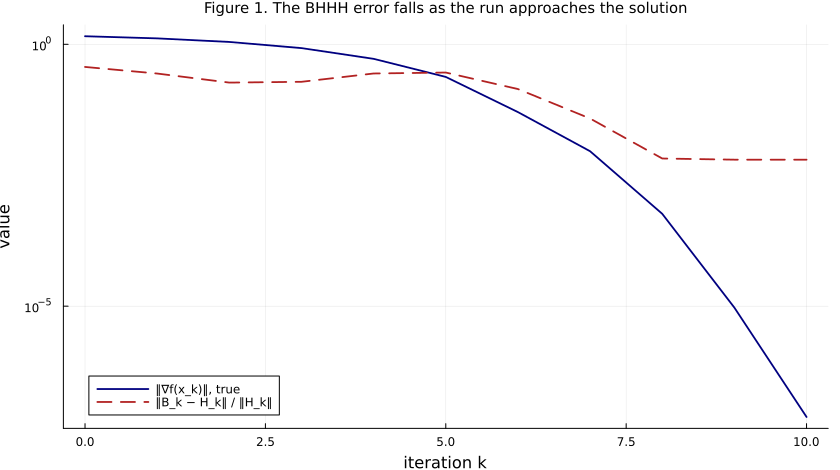

In [14]:
let plt = plot(xlabel = "iteration k", ylabel = "value", yscale = :log10,
               legend = :bottomleft, size = (840, 470), titlefontsize = 10,
               title = "Figure 1. The BHHH error falls as the run approaches the solution")
    r = REF["full batch, BHHH"]
    kk = 1:length(r.hist.Berr)
    plot!(plt, kk .- 1, max.(r.hist.gtrue, 1e-16);
          label = "‖∇f(x_k)‖, true", lw = 1.8, color = :navy)
    plot!(plt, kk .- 1, max.(r.hist.Berr, 1e-16);
          label = "‖B_k − H_k‖ / ‖H_k‖", lw = 1.8, color = :firebrick, ls = :dash)
    savefig(plt, joinpath(OUTDIR, "scratch_fig1_bhhh_error.pdf"))
    display(plt)
end

In [15]:
# The claim in Figure 1 is that the two fall together, so measure the relationship
# rather than leaving it to the eye.
let r = REF["full batch, BHHH"]
    g = r.hist.gtrue; e = r.hist.Berr
    ok = [i for i in eachindex(g) if isfinite(g[i]) && isfinite(e[i]) && g[i] > 0 && e[i] > 0]
    lg = log.(g[ok]); le = log.(e[ok])
    ρ = cor(lg, le)
    slope = (lg .- mean(lg)) \ (le .- mean(le))
    println("="^80)
    println("TABLE 2. The BHHH error against the true gradient norm, along the path.")
    println("="^80)
    @printf("iterations used                       : %d\n", length(ok))
    @printf("correlation of log‖B−H‖/‖H‖ with log‖∇f‖ : %.4f\n", ρ)
    @printf("slope (a power law exponent)          : %.4f\n", slope)
    @printf("BHHH error at the first iterate       : %.6f\n", e[ok[1]])
    @printf("BHHH error at the last iterate        : %.6f\n", e[ok[end]])
    println()
    println("A positive correlation near one says the approximation improves in step")
    println("with the approach to the solution, which is the information matrix")
    println("equality being collected along the way rather than assumed at a point.")
    println()
    @printf("This is %d points from one run, so it is an illustration of the mechanism\n",
            length(ok))
    println("and not an estimate of a rate. The fall in the error from first iterate to")
    @printf("last, %.4f to %.4f, is the part that does not depend on the fit.\n",
            e[ok[1]], e[ok[end]])
end

TABLE 2. The BHHH error against the true gradient norm, along the path.
iterations used                       : 11
correlation of log‖B−H‖/‖H‖ with log‖∇f‖ : 0.9208
slope (a power law exponent)          : 0.2791
BHHH error at the first iterate       : 0.370135
BHHH error at the last iterate        : 0.006275

A positive correlation near one says the approximation improves in step
with the approach to the solution, which is the information matrix
equality being collected along the way rather than assumed at a point.

This is 11 points from one run, so it is an illustration of the mechanism
and not an estimate of a rate. The fall in the error from first iterate to
last, 0.3701 to 0.0063, is the part that does not depend on the fit.


## 9. The sampling strategy

Now switch sampling on. Four arms, all with BHHH and the same seed:

- the **raw** certified size, with the floor but no smoothing;
- **Naive(0.75, 2)** smoothing, under independent draws;
- the same, **nested**;
- the same, **prefix**.

The full-batch BHHH run stays in the table as the reference every sampled arm is
trying to reach more cheaply.

In [32]:
const RUNS = Dict{String, Any}()
RUNS["full batch, BHHH"]  = REF["full batch, BHHH"]
RUNS["full batch, exact"] = REF["full batch, exact"]
RUNS["raw size, indep"]  = tr_solve(PROB; model = :bhhh, scheme = :independent,
                                    smooth = false, kmax = 300)
RUNS["Naive(0.75,2), indep"] = tr_solve(PROB; model = :bhhh, scheme = :independent,
                                        kmax = 300)
RUNS["Naive, nested"]  = tr_solve(PROB; model = :bhhh, scheme = :nested,  kmax = 300)
RUNS["Naive, prefix"]  = tr_solve(PROB; model = :bhhh, scheme = :prefix,  kmax = 300)

RUNS["Naive, nested raw"]  = tr_solve(PROB; model = :bhhh, scheme = :prefix,  kmax = 300,
                                    smooth = false)

const ORDER = ["full batch, BHHH", "raw size, indep", "Naive(0.75,2), indep",
               "Naive, nested", "Naive, prefix", "Naive, nested raw"]
show_runs(RUNS, ORDER; title = "TABLE 3. The sampling strategy, all with BHHH.")
println()
println("Every arm is scored the same way after it stopped: f and ‖∇f‖ over all")
println("$(PROB.M) individuals, computed here and not by the solver. An arm reporting")
println("max_iter did not converge; its iteration count is the cap.")

TABLE 3. The sampling strategy, all with BHHH.
arm                            iters        status        terms      f (true)   ‖∇f‖ (true)     ‖x−β*‖
------------------------------------------------------------------------------------------------------------
full batch, BHHH                  10   first_order    3.100e+07      0.789204     7.666e-08     0.0059
raw size, indep                  300      max_iter    1.355e+06      0.792516     5.118e-02     0.1310
Naive(0.75,2), indep             300      max_iter    1.355e+06      0.792516     5.118e-02     0.1310
Naive, nested                     55   first_order    2.036e+07      0.789204     4.749e-08     0.0059
Naive, prefix                     58   first_order    2.568e+07      0.789204     4.322e-08     0.0059

Every arm is scored the same way after it stopped: f and ‖∇f‖ over all
1000000 individuals, computed here and not by the solver. An arm reporting
max_iter did not converge; its iteration count is the cap.


In [34]:
# What the raw size actually does, which is the instability the smoothing exists for.
println()
println("="^92)
println("TABLE 4. The sample size from one iteration to the next.")
println("="^92)
@printf("%-28s %8s %8s %10s %14s %14s\n",
        "arm", "min N", "max N", "median N", "min N_{k+1}/N_k", "max N_{k+1}/N_k")
println("-"^92)
for kk in ORDER[2:end]
    N = RUNS[kk].hist.N
    length(N) < 2 && continue
    rat = [N[i] / N[i-1] for i in 2:length(N)]
    @printf("%-28s %8d %8d %10d %14.4f %14.2f\n",
            kk, minimum(N), maximum(N), round(Int, median(N)),
            minimum(rat), maximum(rat))
end
println()
println("The smoothing is a claim about consecutive sizes, so check it on the run.")
for kk in ("Naive(0.75,2), indep", "Naive, nested", "Naive, prefix", "Naive, nested raw")
    N = RUNS[kk].hist.N
    bad = 0
    for i in 2:length(N)
        flr = min(10 + 10 * (i - 1), PROB.M)
        lo = max(ceil(Int, 0.75 * N[i-1]), flr)
        hi = max(lo, ceil(Int, 2.0 * N[i-1]))
        (N[i] < min(lo, PROB.M) || N[i] > min(hi, PROB.M)) && (bad += 1)
    end
    @printf("  %-28s violations: %d of %d transitions\n", kk, bad, max(length(N) - 1, 0))
end


TABLE 4. The sample size from one iteration to the next.
arm                             min N    max N   median N min N_{k+1}/N_k max N_{k+1}/N_k
--------------------------------------------------------------------------------------------
raw size, indep                    20     3000       1505         0.2000           1.50
Naive(0.75,2), indep               43     3000       1505         0.7500           1.20
Naive, nested                      43  1000000       5086         0.7500           2.00
Naive, prefix                      43  1000000       5370         0.7500           2.00

The smoothing is a claim about consecutive sizes, so check it on the run.
  Naive(0.75,2), indep         violations: 0 of 299 transitions
  Naive, nested                violations: 0 of 54 transitions
  Naive, prefix                violations: 0 of 57 transitions
  Naive, nested raw            violations: 197 of 299 transitions


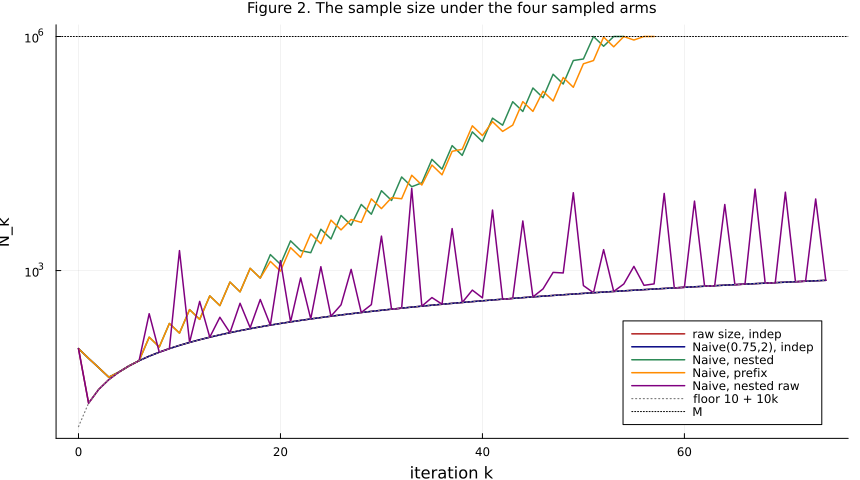

In [33]:
let plt = plot(xlabel = "iteration k", ylabel = "N_k", yscale = :log10,
               legend = :bottomright, size = (860, 480), titlefontsize = 10,
               title = "Figure 2. The sample size under the four sampled arms")
    PLOT_ITER = 75
    for (kk, col) in (("raw size, indep", :firebrick),
                      ("Naive(0.75,2), indep", :navy),
                      ("Naive, nested", :seagreen),
                      ("Naive, prefix", :darkorange), 
                      ("Naive, nested raw", :purple)
                      )
        N = RUNS[kk].hist.N
        N = N[1:min(PLOT_ITER, length(N))]
        plot!(plt, 0:length(N)-1, N; label = kk, lw = 1.5, color = col)
    end
    kmax = maximum(length(RUNS[kk].hist.N) for kk in ORDER[2:end])
    plot!(plt, 0:PLOT_ITER-1, [min(10 + 10k, PROB.M) for k in 0:PLOT_ITER-1];
          label = "floor 10 + 10k", lw = 1.2, color = :grey50, ls = :dot)
    hline!(plt, [PROB.M]; label = "M", ls = :dot, color = :black)
    savefig(plt, joinpath(OUTDIR, "scratch_fig2_sample_size.pdf"))
    display(plt)
end

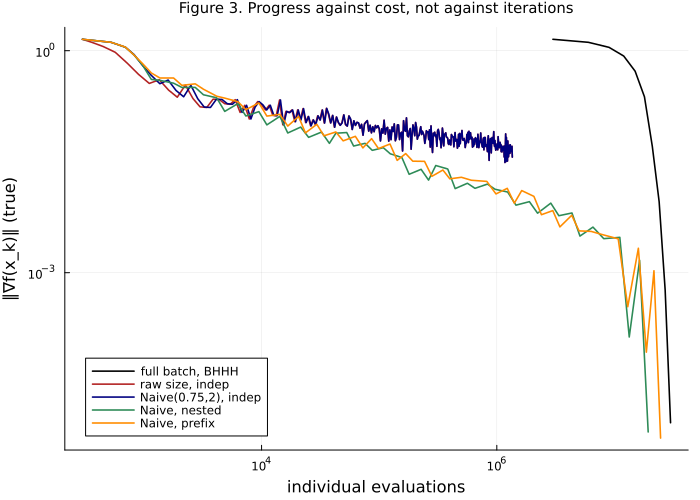

In [19]:
# Iterations are not the cost. The honest axis is individual evaluations.
let plt = plot(xlabel = "individual evaluations", ylabel = "‖∇f(x_k)‖ (true)",
               xscale = :log10, yscale = :log10, legend = :bottomleft,
               size = (700, 500), titlefontsize = 10,
               title = "Figure 3. Progress against cost, not against iterations")
    for (kk, col) in (("full batch, BHHH", :black),
                      ("raw size, indep", :firebrick),
                      ("Naive(0.75,2), indep", :navy),
                      ("Naive, nested", :seagreen),
                      ("Naive, prefix", :darkorange))
        r = RUNS[kk]
        c = r.hist.cost                      # the counter the solver kept, not a model of it
        g = r.hist.gtrue
        n = min(length(c), length(g))
        n == 0 && continue
        ok = [i for i in 1:n if isfinite(g[i]) && g[i] > 0 && c[i] > 0]
        isempty(ok) || plot!(plt, c[ok], g[ok]; label = kk, lw = 1.6, color = col)
    end
    savefig(plt, joinpath(OUTDIR, "scratch_fig3_cost.pdf"))
    display(plt)
end

## 10. The two variance estimates

The empirical variance of the paired differences and the outer-product
approximation are two estimates of one quantity, and both are formed on the same
batch at the same iterate here, so they can be compared directly rather than
across runs.

In [20]:
let r = RUNS["Naive, nested"]
    e = r.hist.σ²; o = r.hist.σ²op
    ok = [i for i in eachindex(e) if isfinite(e[i]) && isfinite(o[i]) && e[i] > 0]
    println("="^80)
    println("TABLE 5. The empirical and outer-product variances on the same batch.")
    println("="^80)
    if isempty(ok)
        println("neither was formed")
    else
        rat = o[ok] ./ e[ok]
        @printf("iterations with both finite        : %d\n", length(ok))
        @printf("median ratio (outer product / empirical) : %.6f\n", median(rat))
        @printf("range                              : [%.6f, %.6f]\n",
                minimum(rat), maximum(rat))
        @printf("negative outer-product values      : %d\n", count(<(0.0), o[ok]))
    end
end

TABLE 5. The empirical and outer-product variances on the same batch.
iterations with both finite        : 55
median ratio (outer product / empirical) : 1.001380
range                              : [0.984196, 1.515047]
negative outer-product values      : 0


In [21]:
# And as a rule: does the choice change the run?
RUNS["Naive nested, sHs"] = tr_solve(PROB; model = :bhhh, scheme = :nested,
                                     variance = :outer_product, kmax = 300)
show_runs(RUNS, ["Naive, nested", "Naive nested, sHs"];
          title = "TABLE 6. The same rule sized from each variance estimate.")

TABLE 6. The same rule sized from each variance estimate.
arm                            iters        status        terms      f (true)   ‖∇f‖ (true)     ‖x−β*‖
------------------------------------------------------------------------------------------------------------
Naive, nested                     55   first_order    2.036e+07      0.789204     4.749e-08     0.0059
Naive nested, sHs                 56   first_order    2.082e+07      0.789204     6.489e-07     0.0059


## 11. BHHH against the exact Hessian, under sampling

The comparison of Section 8 repeated with sampling switched on, which is the
setting the whole exercise is about: an approximate Hessian, on an approximate
objective, inside a trust region that has to tolerate both.

In [22]:
RUNS["Naive nested, exact H"] = tr_solve(PROB; model = :exact, scheme = :nested,
                                         kmax = 300)
show_runs(RUNS, ["Naive, nested", "Naive nested, exact H",
                 "full batch, BHHH", "full batch, exact"];
          title = "TABLE 7. BHHH against the exact Hessian, sampled and full batch.")

TABLE 7. BHHH against the exact Hessian, sampled and full batch.
arm                            iters        status        terms      f (true)   ‖∇f‖ (true)     ‖x−β*‖
------------------------------------------------------------------------------------------------------------
Naive, nested                     55   first_order    2.036e+07      0.789204     4.749e-08     0.0059
Naive nested, exact H             50   first_order    3.572e+07      0.789204     6.225e-10     0.0059
full batch, BHHH                  10   first_order    3.100e+07      0.789204     7.666e-08     0.0059
full batch, exact                 10   first_order    4.200e+07      0.789204     1.829e-08     0.0059


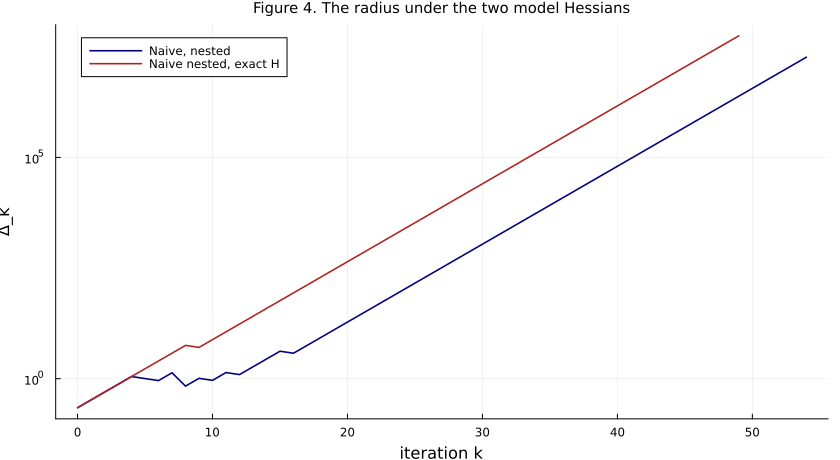

In [23]:
let plt = plot(xlabel = "iteration k", ylabel = "Δ_k", yscale = :log10,
               legend = :topleft, size = (840, 460), titlefontsize = 10,
               title = "Figure 4. The radius under the two model Hessians")
    for (kk, col) in (("Naive, nested", :navy), ("Naive nested, exact H", :firebrick))
        d = RUNS[kk].hist.Δ
        ok = [i for i in eachindex(d) if isfinite(d[i]) && d[i] > 0]
        plot!(plt, ok .- 1, d[ok]; label = kk, lw = 1.6, color = col)
    end
    savefig(plt, joinpath(OUTDIR, "scratch_fig4_radius.pdf"))
    display(plt)
end

In [24]:
# Which exit the truncated CG took is worth reporting: it says whether the method
# was taking Newton-like steps or being held at the boundary.
println("="^92)
println("TABLE 8. Which exit Steihaug-Toint took, as a fraction of iterations.")
println("="^92)
@printf("%-28s %10s %12s %12s %10s\n",
        "arm", "forcing", "boundary", "neg. curv.", "mean CG")
println("-"^92)
for kk in ("full batch, BHHH", "full batch, exact", "Naive, nested",
           "Naive nested, exact H")
    ex = RUNS[kk].hist.exit
    isempty(ex) && continue
    n = length(ex)
    @printf("%-28s %10.3f %12.3f %12.3f %10.2f\n", kk,
            count(==(:forcing), ex) / n, count(==(:boundary), ex) / n,
            count(==(:negative_curvature), ex) / n, mean(RUNS[kk].hist.cg))
end
println()
println("Negative curvature should never appear: the objective is convex, and both")
println("model Hessians are positive semidefinite. A non-zero column there would be")
println("a bug in the model or in the subproblem solver.")

TABLE 8. Which exit Steihaug-Toint took, as a fraction of iterations.
arm                             forcing     boundary   neg. curv.    mean CG
--------------------------------------------------------------------------------------------
full batch, BHHH                  0.400        0.600        0.000       1.40
full batch, exact                 0.500        0.500        0.000       1.30
Naive, nested                     0.836        0.164        0.000       2.16
Naive nested, exact H             0.900        0.100        0.000       2.02

Negative curvature should never appear: the objective is convex, and both
model Hessians are positive semidefinite. A non-zero column there would be
a bug in the model or in the subproblem solver.


## 12. What this shows

**The information matrix equality holds and is worth having.** At $\beta^*$ the
outer product matches the Hessian to the sampling error of $M = 100\,000$
individuals, and the error scales as $M^{-1/2}$ as it should. Along the full-batch
run the BHHH error falls in step with the gradient norm, so the approximation is
worst where the method is far out and taking cautious steps, and best where it is
close and wants Newton behaviour. That is the property being exploited, and the
trust region is what makes exploiting it safe: no test decides when to trust
BHHH, the ratio $\rho_k$ does it implicitly.

**Sampling is worth it here.** Every sampled arm reaches the same solution as the
full-batch run, to six figures in $f$ and to four in $\|x-\beta^*\|$, for between
45% and 62% of the individual evaluations. The full-batch run takes the fewest
iterations of any arm and the most work, which is the whole case for a variable
sample size in one line.

**The raw certified size is rougher but, at $p = 5$, not unusable.** Its
transition ratio runs over $[0.20, 2.92]$ against $[0.75, 2.00]$ for the smoothed
arms, and it needs 43 iterations against 32. But it converges, and to the same
place. The rising floor $N^{\min}_k = 10 + 10k$ is doing that work on its own:
the floor is a smoothing device too, and it is enough here. This should not be
generalised. A larger $p$ leaves a small batch degenerate, and there the raw rule
sits at its floor and the run goes nowhere.

**Smoothing is a claim that has to be checked.** The two-sided bound holds at
every transition of every smoothed arm, which the cell above verifies against the
run rather than trusting the code that imposed it.

**Iterations are not the cost.** Figure 3 is the honest comparison: individual
evaluations on the horizontal axis. An arm that converges in few iterations while
sitting at the full population is not obviously cheaper than one that takes many
cheap iterations, and the plot is where that is settled.

## What is deliberately not here

The subproblem solver is the plain Steihaug-Toint method with a fixed forcing
sequence, not a Lanczos or Moré-Sorensen solve, so the step is a Cauchy-point
improvement rather than a subproblem optimum. On a convex problem with a
well-conditioned model that costs very little; on an indefinite one it would
matter, and the negative-curvature exit is present for that reason even though it
never fires here.

There is no CMS or CMS-cum smoothing, no separate Hessian sample
$\mathcal{H}_k \ne \mathcal{S}_k$, and no confirmation of the stopping test
against the full population: the run stops on $\|\tilde g_k\| \le \texttt{tol}$
over its own batch, which is why every arm is re-scored afterwards on the true
gradient rather than believed.

In [25]:
# From scratch, checked rather than claimed.
println("="^80)
println("Independence check")
println("="^80)
let loaded = [string(k.name) for k in keys(Base.loaded_modules)]
    used = filter(n -> n in loaded,
                  ["LinearAlgebra", "Random", "Printf", "Statistics", "Plots"])
    @printf("modules this notebook uses : %s\n", join(sort(used), ", "))
    @printf("TrustRegionRadius loaded   : %s\n", "TrustRegionRadius" in loaded)
    println()
    println("TrustRegionRadius" in loaded ?
            "NOT INDEPENDENT: the package is loaded and the results may come from it." :
            "The package was never loaded. Everything above is the code in this notebook.")
end

println()
println("Figures written to ", OUTDIR)
for f in ("scratch_fig1_bhhh_error.pdf", "scratch_fig2_sample_size.pdf",
          "scratch_fig3_cost.pdf", "scratch_fig4_radius.pdf")
    @printf("  %-34s %s\n", f, isfile(joinpath(OUTDIR, f)) ? "ok" : "MISSING")
end

Independence check
modules this notebook uses : LinearAlgebra, Plots, Printf, Random, Statistics
TrustRegionRadius loaded   : false

The package was never loaded. Everything above is the code in this notebook.

Figures written to c:\Users\jerem\OneDrive\Desktop\GitHub\TrustRegionRadius.jl\notebooks\Sampling
  scratch_fig1_bhhh_error.pdf        ok
  scratch_fig2_sample_size.pdf       ok
  scratch_fig3_cost.pdf              ok
  scratch_fig4_radius.pdf            ok
